In [1]:
# ==========================
# 1. Import Library
# ==========================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# ==========================
# 2. Tentukan Path Dataset
# ==========================
train_folder = r"F:\Project ML\ODIR-5K\Training Images"
test_folder = r"F:\Project ML\ODIR-5K\Testing Images"
excel_path = r"F:\Project ML\ODIR-5K\data.xlsx"

IMG_SIZE = (128, 128)
CLASSES = ['Normal', 'Cataract']

print("Dataset paths configured!")

Dataset paths configured!


In [6]:
# ==========================
# 3. Fungsi Load Dataset dari Excel
# ==========================
def load_images_from_excel(base_folder, excel_path):
    df = pd.read_excel(excel_path)
    X, y = [], []

    for _, row in df.iterrows():
        left_img = row['Left-Fundus']
        right_img = row['Right-Fundus']
        left_label_text = str(row['Left-Diagnostic Keywords']).lower()
        right_label_text = str(row['Right-Diagnostic Keywords']).lower()

        def get_label(text):
            if 'cataract' in text:
                return 1
            elif 'normal fundus' in text:
                return 0
            else:
                return None

        # Kiri
        left_label = get_label(left_label_text)
        if left_label is not None:
            path = os.path.join(base_folder, left_img)
            if os.path.exists(path):
                img = cv2.imread(path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                X.append(img)
                y.append(left_label)

        # Kanan
        right_label = get_label(right_label_text)
        if right_label is not None:
            path = os.path.join(base_folder, right_img)
            if os.path.exists(path):
                img = cv2.imread(path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                X.append(img)
                y.append(right_label)

    return np.array(X), np.array(y)

def load_images_without_label(folder):
    X = []
    for file in os.listdir(folder):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(folder, file)
            img = cv2.imread(path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                X.append(img)
    return np.array(X)

print("Loading functions defined!")

Loading functions defined!


In [7]:
# ==========================
# 4. Load Data
# ==========================
X_train, y_train = load_images_from_excel(train_folder, excel_path)
X_test = load_images_without_label(test_folder)

print("Jumlah data train :", len(X_train))
print("Jumlah data test  :", len(X_test))
print("Jumlah Normal     :", np.sum(y_train == 0))
print("Jumlah Cataract   :", np.sum(y_train == 1))

Jumlah data train : 3411
Jumlah data test  : 1000
Jumlah Normal     : 3098
Jumlah Cataract   : 313


In [8]:
# ==========================
# 5. Dataset Original 
# ==========================
def plot_image(X, y, label_value, label_name, num_samples=3):
    """Menampilkan beberapa contoh gambar berdasarkan label tertentu"""
    indices = np.where(y == label_value)[0][:num_samples]
    plt.figure(figsize=(10, 4))
    
    for i, idx in enumerate(indices, 1):
        plt.subplot(1, num_samples, i)
        plt.imshow(X[idx])
        plt.title(f"{label_name}", fontsize=11)
        plt.axis("off")
    
    plt.show()



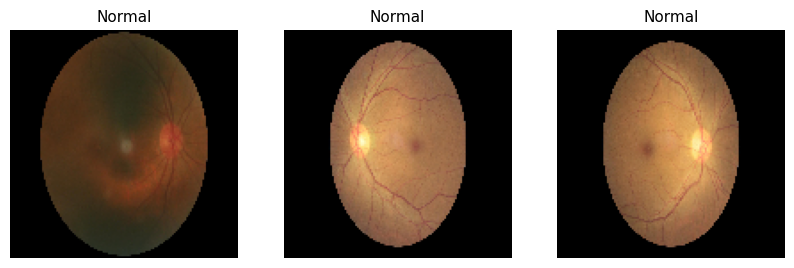

In [9]:
plot_image(X_train, y_train, 0, "Normal", num_samples=3)


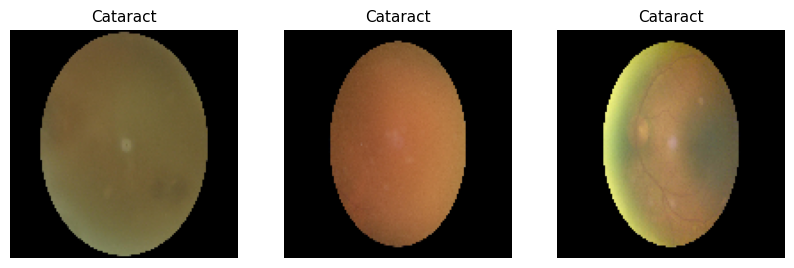

In [10]:
plot_image(X_train, y_train, 1, "Cataract", num_samples=3)

In [11]:
# ==========================
# 5.1 Simpan Dataset Setelah Pelabelan
# ==========================
save_folder = r"F:\Project ML\ODIR-5K\dataset_labeled"

# Buat folder untuk setiap kelas
for cls in CLASSES:
    os.makedirs(os.path.join(save_folder, cls), exist_ok=True)

def save_labeled_images(X, y, save_path):
    for i, (img, label) in enumerate(zip(X, y)):
        label_name = CLASSES[label]
        save_dir = os.path.join(save_path, label_name)
        filename = f"{label_name.lower()}_{i+1:04d}.jpg"
        cv2.imwrite(os.path.join(save_dir, filename), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

save_labeled_images(X_train, y_train, save_folder)

print(f"Dataset hasil pelabelan telah disimpan di: {save_folder}")
print("Jumlah Normal :", np.sum(y_train == 0))
print("Jumlah Cataract:", np.sum(y_train == 1))

Dataset hasil pelabelan telah disimpan di: F:\Project ML\ODIR-5K\dataset_labeled
Jumlah Normal : 3098
Jumlah Cataract: 313


In [12]:
# ==========================
# 6. Normalisasi Nilai Piksel (0–1)
# ==========================
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("\nSetelah normalisasi:")
print("Nilai piksel min:", X_train.min())
print("Nilai piksel max:", X_train.max())


Setelah normalisasi:
Nilai piksel min: 0.0
Nilai piksel max: 1.0


In [13]:
# ==========================
# 7. Augmentasi Data 
# ==========================
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fit generator ke data training
datagen.fit(X_train)
print("Data augmentation configured!")

Data augmentation configured!


In [14]:
# ==========================
# 8.🔧 Tambahan: Augmentasi Khusus Kelas Minoritas (Cataract)
# ==========================
X_cataract = X_train[y_train == 1]
y_cataract = y_train[y_train == 1]

augmented_images = []
augmented_labels = []

for batch in datagen.flow(X_cataract, y_cataract, batch_size=32):
    augmented_images.extend(batch[0])
    augmented_labels.extend(batch[1])
    if len(augmented_images) >= len(X_cataract) * 3:
        break

X_train = np.concatenate([X_train, np.array(augmented_images)])
y_train = np.concatenate([y_train, np.array(augmented_labels)])

print("Setelah augmentasi tambahan:")
print("Normal :", np.sum(y_train == 0))
print("Cataract:", np.sum(y_train == 1))

Setelah augmentasi tambahan:
Normal : 3098
Cataract: 1252


In [15]:
# ==========================
# 9. Ekstraksi Fitur HOG + LBP + Warna
# ==========================
def extract_features(img):
    gray = cv2.cvtColor((img * 255).astype('uint8'), cv2.COLOR_RGB2GRAY)
    hog_features, _ = hog(gray, orientations=9, pixels_per_cell=(8,8),
                          cells_per_block=(2,2), block_norm='L2-Hys',
                          visualize=True, transform_sqrt=True)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(59), range=(0,58))
    lbp_hist = lbp_hist / np.sum(lbp_hist)
    color_mean = np.mean(img, axis=(0,1))
    color_std = np.std(img, axis=(0,1))
    return np.hstack([hog_features, lbp_hist, color_mean, color_std])

print("Extracting features...")
X_features = np.array([extract_features(img) for img in X_train])
print("Bentuk fitur hasil ekstraksi:", X_features.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)

print("Setelah PCA:", X_pca.shape)

X_train_pca, X_val_pca, y_train_pca, y_val_pca = train_test_split(
    X_pca, y_train, test_size=0.2, stratify=y_train, random_state=42
)

Extracting features...
Bentuk fitur hasil ekstraksi: (4350, 8164)
Setelah PCA: (4350, 100)


In [16]:
# ==========================
# 10. 🔧 Tambahan: Class Weight untuk Imbalance
# ==========================
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_pca), y=y_train_pca)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(0.7021791767554479), 1: np.float64(1.7365269461077844)}


In [17]:
# ==========================
# 11. Pelatihan Model SVM + Grid Search
# ==========================
param_grid = {
    'C': [1, 10, 50],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

print("Training SVM with Grid Search...")
grid = GridSearchCV(SVC(class_weight=class_weights_dict), param_grid, cv=3, scoring='f1_macro', verbose=2)
grid.fit(X_train_pca, y_train_pca)
svm_model = grid.best_estimator_

y_pred = svm_model.predict(X_val_pca)

acc = accuracy_score(y_val_pca, y_pred)
print(f"Akurasi Model SVM: {acc:.4f}")
print("Recall Cataract:", recall_score(y_val_pca, y_pred, pos_label=1))
print("F1-score (macro):", f1_score(y_val_pca, y_pred, average='macro'))

Training SVM with Grid Search...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.2s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.2s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.8s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.5s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.5s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   0.5s
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   0.4s
[CV] END .......

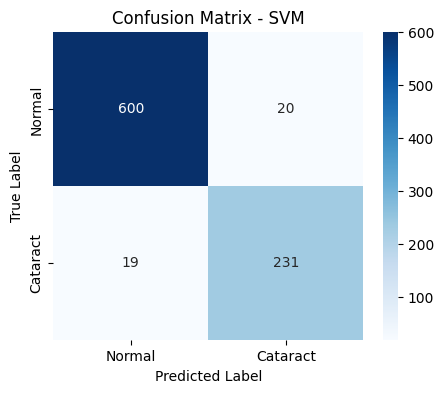


Classification Report SVM:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       620
    Cataract       0.92      0.92      0.92       250

    accuracy                           0.96       870
   macro avg       0.94      0.95      0.95       870
weighted avg       0.96      0.96      0.96       870



In [18]:
# ==========================
# 12. Confusion Matrix SVM
# ==========================
cm = confusion_matrix(y_val_pca, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM")
plt.show()

print("\nClassification Report SVM:")
print(classification_report(y_val_pca, y_pred, target_names=CLASSES))

Jumlah data salah klasifikasi: 39


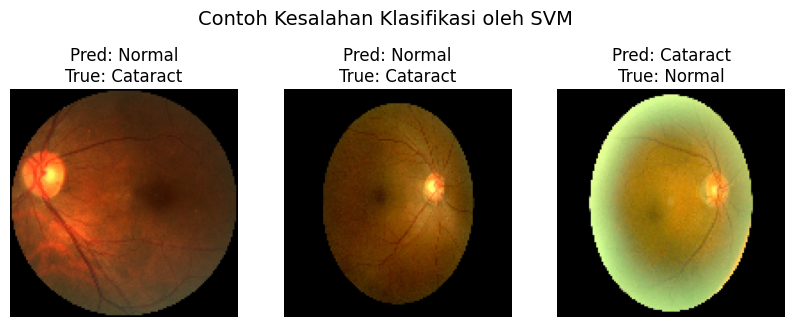

In [19]:
# ==========================
# 13. Analisis Kesalahan (Error Analysis) SVM
# ==========================
misclassified_idx = np.where(y_val_pca != y_pred)[0]
print(f"Jumlah data salah klasifikasi: {len(misclassified_idx)}")

num_display = min(3, len(misclassified_idx))
plt.figure(figsize=(10, 4))
for i, idx in enumerate(misclassified_idx[:num_display], 1):
    plt.subplot(1, num_display, i)
    plt.imshow(X_train[idx])
    plt.title(f"Pred: {CLASSES[y_pred[idx]]}\nTrue: {CLASSES[y_val_pca[idx]]}")
    plt.axis("off")
plt.suptitle("Contoh Kesalahan Klasifikasi oleh SVM", fontsize=14)
plt.show()

In [20]:
# ==========================
# 14. IMPLEMENTASI CNN (TANPA PRE-TRAINED)
# ==========================
print("\n" + "="*50)
print("IMPLEMENTASI CNN (TANPA PRE-TRAINED)")
print("="*50)

def create_cnn_model(input_shape=(128, 128, 3)):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fourth Convolutional Block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Create and compile CNN model
cnn_model = create_cnn_model()
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print(cnn_model.summary())

# Split data for CNN
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=1e-7,
    verbose=1
)


IMPLEMENTASI CNN (TANPA PRE-TRAINED)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 9,697,953 (36.99 MB)

 Trainable params: 9,695,457 (36.99 MB)

 Non-trainable params: 2,496 (9.75 KB)

None


In [21]:
# Train CNN model
print("\nTraining CNN Model...")
history = cnn_model.fit(
    X_train_cnn, y_train_cnn,
    batch_size=32,
    epochs=20,
    validation_data=(X_val_cnn, y_val_cnn),
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate CNN model
cnn_loss, cnn_accuracy, cnn_precision, cnn_recall = cnn_model.evaluate(X_val_cnn, y_val_cnn)
print(f"\nCNN Model Evaluation:")
print(f"Accuracy: {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall: {cnn_recall:.4f}")

# CNN Predictions
y_pred_cnn = (cnn_model.predict(X_val_cnn) > 0.5).astype("int32")


Training CNN Model...
Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.6046 - loss: 2.2057 - precision: 0.3783 - recall: 0.5798 - val_accuracy: 0.2874 - val_loss: 2.0972 - val_precision: 0.2874 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7060 - loss: 1.6806 - precision: 0.4933 - recall: 0.7715 - val_accuracy: 0.2874 - val_loss: 1.9142 - val_precision: 0.2874 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7845 - loss: 1.3238 - precision: 0.5899 - recall: 0.8253 - val_accuracy: 0.2862 - val_loss: 2.6131 - val_precision: 0.2865 - val_recall: 0.9960 - learning_rate: 0.0010
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8615 - loss: 1.0244 - precision: 0.7087 - recall: 0.8812 - val_accuracy: 0.2897 - val_loss: 3.3480 - val_precision: 0.2880 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━

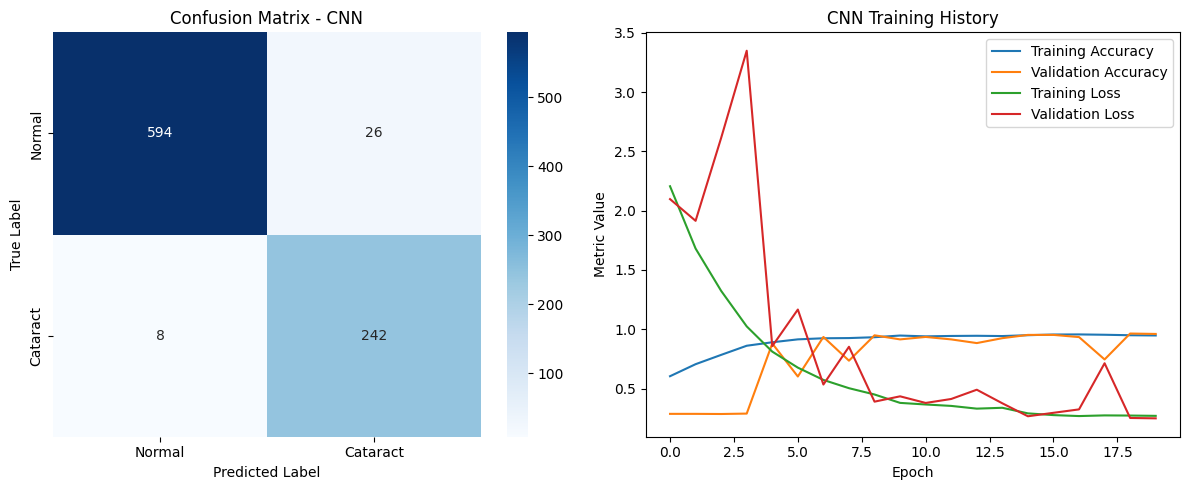


CNN Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97       620
    Cataract       0.90      0.97      0.93       250

    accuracy                           0.96       870
   macro avg       0.94      0.96      0.95       870
weighted avg       0.96      0.96      0.96       870



In [22]:
# CNN Confusion Matrix
cm_cnn = confusion_matrix(y_val_cnn, y_pred_cnn)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN")

# Plot training history
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Training History')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend()
plt.tight_layout()
plt.show()

print("\nCNN Classification Report:")
print(classification_report(y_val_cnn, y_pred_cnn, target_names=CLASSES))

In [30]:
# ==========================
# 15. TRANSFER LEARNING + FINE-TUNING (OPTIMIZED FOR CPU)
# ==========================
print("\n" + "="*50)
print("TRANSFER LEARNING + FINE-TUNING (CPU OPTIMIZED)")
print("="*50)

def create_lightweight_transfer_model(input_shape=(128, 128, 3), base_trainable=False):
    print("Creating MobileNetV2 (Lightweight) base model...")
    
    # Gunakan MobileNetV2 yang lebih ringan untuk CPU
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base_model.trainable = base_trainable
    
    print("Building custom classifier...")
    # Build custom classifier on top
    inputs = tf.keras.Input(shape=input_shape)
    
    # Preprocessing untuk MobileNetV2
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    
    # Base model
    x = base_model(x, training=False)
    x = layers.Dropout(0.3)(x)  # Kurangi dropout
    x = layers.Dense(128, activation='relu')(x)  # Kurangi neurons
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs, outputs)
    print("✅ Lightweight transfer learning model created successfully!")
    return model, base_model

# Phase 1: Train hanya classifier (base model frozen)
print("\n=== Phase 1: Training Classifier (Base Frozen) ===")
print("Creating lightweight model...")
transfer_model, base_model = create_lightweight_transfer_model(
    input_shape=(128, 128, 3), 
    base_trainable=False
)

print("Compiling model...")
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Learning rate lebih tinggi
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("📋 Model summary:")
transfer_model.summary()

# Callbacks untuk transfer learning
checkpoint_cb = ModelCheckpoint(
    "best_lightweight_transfer_model.h5",
    save_best_only=True,
    monitor='val_accuracy',  # Monitor accuracy instead of loss
    verbose=1
)

# Simplify early stopping
simple_early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print(f"\n📊 Starting training with:")
print(f"- Training samples: {len(X_train_cnn)}")
print(f"- Validation samples: {len(X_val_cnn)}")
print(f"- Batch size: 16 (smaller for CPU)")
print(f"- Epochs: 10")
print(f"- Using CPU only")

# Test prediction dulu untuk pastikan model work
print("\n🧪 Testing model with small sample...")
try:
    test_pred = transfer_model.predict(X_train_cnn[:1], verbose=0)
    print(f"✅ Model test passed! Prediction: {test_pred[0][0]:.4f}")
except Exception as e:
    print(f"❌ Model test failed: {e}")
    exit()

# Train classifier
print("\n" + "🚀 STARTING TRANSFER LEARNING TRAINING")
print("=" * 40)

# Gunakan steps_per_epoch untuk mempercepat feedback
import math
steps_per_epoch = min(50, math.ceil(len(X_train_cnn) / 16))
validation_steps = min(20, math.ceil(len(X_val_cnn) / 16))

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

history_transfer = transfer_model.fit(
    X_train_cnn, y_train_cnn,
    batch_size=16,  # Smaller batch size for CPU
    epochs=10,      # Fewer epochs
    validation_data=(X_val_cnn, y_val_cnn),
    class_weight=class_weights_dict,
    callbacks=[simple_early_stop, checkpoint_cb],
    verbose=1,
    shuffle=True
)

print("\n✅ Transfer learning training completed!")

# Evaluate transfer learning model
print("\n📈 Evaluating model...")
transfer_loss, transfer_accuracy, transfer_precision, transfer_recall = transfer_model.evaluate(
    X_val_cnn, y_val_cnn, verbose=1
)

print(f"\n" + "="*50)
print("🎯 TRANSFER LEARNING RESULTS (FROZEN BASE)")
print("="*50)
print(f"Accuracy: {transfer_accuracy:.4f}")
print(f"Precision: {transfer_precision:.4f}")
print(f"Recall: {transfer_recall:.4f}")
print(f"Loss: {transfer_loss:.4f}")


TRANSFER LEARNING + FINE-TUNING (CPU OPTIMIZED)

=== Phase 1: Training Classifier (Base Frozen) ===
Creating lightweight model...
Creating MobileNetV2 (Lightweight) base model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Building custom classifier...
✅ Lightweight transfer learning model created successfully!
Compiling model...
📋 Model summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


📊 Starting training with:
- Training samples: 3480
- Validation samples: 870
- Batch size: 16 (smaller for CPU)
- Epochs: 10
- Using CPU only

🧪 Testing model with small sample...
✅ Model test passed! Prediction: 0.4137

🚀 STARTING TRANSFER LEARNING TRAINING
Steps per epoch: 50
Validation steps: 20
Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5021 - loss: 0.8647 - precision: 0.2912 - recall: 0.5120
Epoch 1: val_accuracy improved from None to 0.28736, saving model to best_lightweight_transfer_model.h5


218/218 ━━━━━━━━━━━━━━━━━━━━ 43s 156ms/step - accuracy: 0.5063 - loss: 0.8173 - precision: 0.2968 - recall: 0.5220 - val_accuracy: 0.2874 - val_loss: 1.4935 - val_precision: 0.2874 - val_recall: 1.0000
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5253 - loss: 0.7359 - precision: 0.3059 - recall: 0.5389
Epoch 2: val_accuracy improved from 0.28736 to 0.72644, saving model to best_lightweight_transfer_model.h5


218/218 ━━━━━━━━━━━━━━━━━━━━ 30s 135ms/step - accuracy: 0.5302 - loss: 0.7441 - precision: 0.3104 - recall: 0.5170 - val_accuracy: 0.7264 - val_loss: 0.6386 - val_precision: 0.5600 - val_recall: 0.2240
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5011 - loss: 0.7565 - precision: 0.3274 - recall: 0.5561
Epoch 3: val_accuracy did not improve from 0.72644
218/218 ━━━━━━━━━━━━━━━━━━━━ 29s 132ms/step - accuracy: 0.5089 - loss: 0.7283 - precision: 0.3063 - recall: 0.5579 - val_accuracy: 0.2874 - val_loss: 0.9420 - val_precision: 0.2874 - val_recall: 1.0000
Epoch 4/10
217/218 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5578 - loss: 0.7097 - precision: 0.3148 - recall: 0.4904
Epoch 4: val_accuracy did not improve from 0.72644
218/218 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - accuracy: 0.5578 - loss: 0.7032 - precision: 0.3282 - recall: 0.5120 - val_accuracy: 0.6954 - val_loss: 0.6565 - val_precision: 0.4576 - val_recall: 0.3240
Epoch 5/10
217/218 ━━━━━━━━━━━━━━━━━━━━ 0s

In [31]:
# Phase 2: Fine-tuning (unfreeze beberapa layer)
print("\n=== Phase 2: Fine-tuning (Unfreeze Layers) ===")

# Unfreeze lapisan atas base model
base_model.trainable = True

# Freeze lapisan awal, unfreeze lapisan akhir
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile dengan learning rate yang lebih rendah
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print(f"Number of trainable layers: {sum([layer.trainable for layer in base_model.layers])}")

# Fine-tuning
history_finetune = transfer_model.fit(
    X_train_cnn, y_train_cnn,
    batch_size=16,  # Batch size lebih kecil untuk fine-tuning
    epochs=10,
    validation_data=(X_val_cnn, y_val_cnn),
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr, checkpoint_cb],
    verbose=1
)

# Evaluate fine-tuned model
finetune_loss, finetune_accuracy, finetune_precision, finetune_recall = transfer_model.evaluate(X_val_cnn, y_val_cnn)
print(f"\nFine-tuned Model Evaluation:")
print(f"Accuracy: {finetune_accuracy:.4f}")
print(f"Precision: {finetune_precision:.4f}")
print(f"Recall: {finetune_recall:.4f}")

# Fine-tuned predictions
y_pred_finetune = (transfer_model.predict(X_val_cnn) > 0.5).astype("int32")


=== Phase 2: Fine-tuning (Unfreeze Layers) ===
Number of trainable layers: 30
Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5535 - loss: 0.8130 - precision: 0.3460 - recall: 0.6074
Epoch 1: val_accuracy did not improve from 0.72644
218/218 ━━━━━━━━━━━━━━━━━━━━ 58s 179ms/step - accuracy: 0.6101 - loss: 0.7094 - precision: 0.3964 - recall: 0.6776 - val_accuracy: 0.7126 - val_loss: 3.5350 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6892 - loss: 0.5803 - precision: 0.4873 - recall: 0.7951
Epoch 2: val_accuracy did not improve from 0.72644
218/218 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - accuracy: 0.6905 - loss: 0.5738 - precision: 0.4775 - recall: 0.7934 - val_accuracy: 0.7126 - val_loss: 3.2952 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7064 - loss: 0.5478 - pre


PERBANDINGAN SEMUA MODEL


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Perbandingan Semua Model:
                             Model  Accuracy  Precision    Recall  F1-Score
0        SVM + Feature Engineering  0.955172   0.944812  0.945871  0.945339
1                 CNN from Scratch  0.960920   0.902985  0.963032  0.953270
2  Transfer Learning + Fine-tuning  0.712644   0.356322  0.500000  0.416107


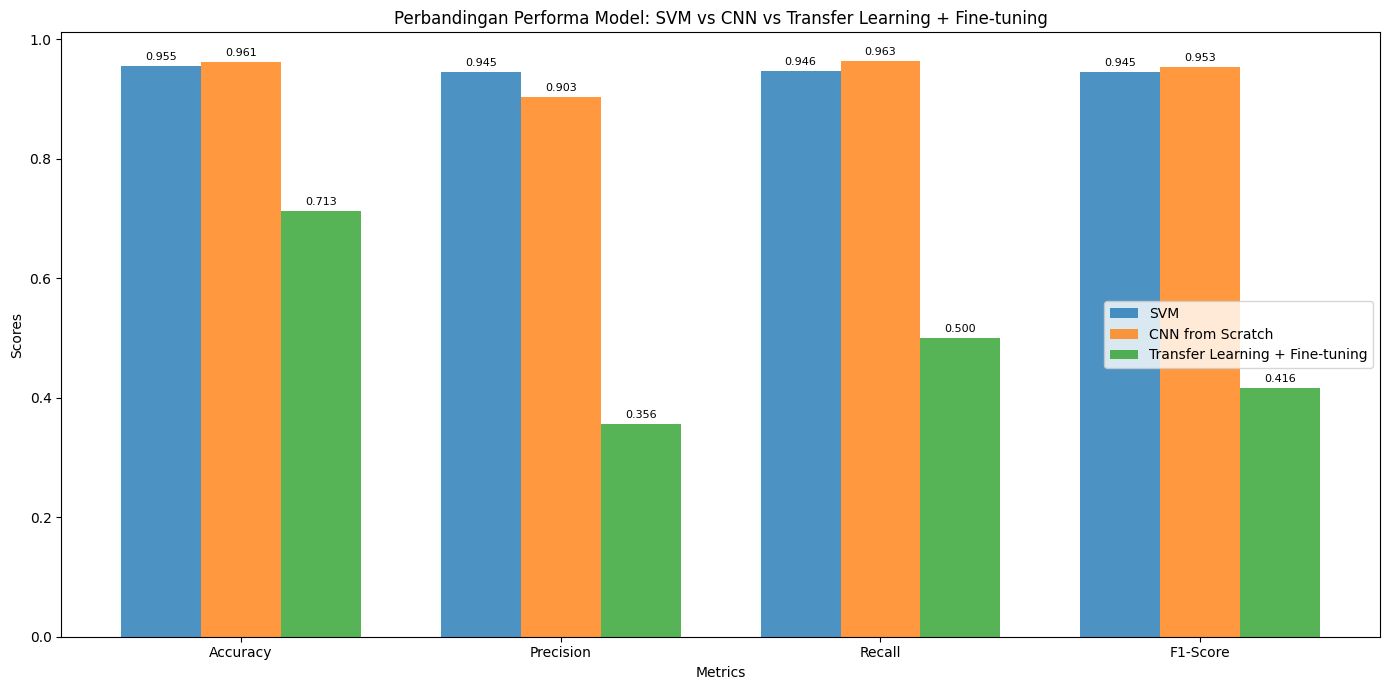

In [32]:
# ==========================
# 16. PERBANDINGAN SEMUA MODEL
# ==========================
print("\n" + "="*50)
print("PERBANDINGAN SEMUA MODEL")
print("="*50)

# SVM Metrics
svm_f1 = f1_score(y_val_pca, y_pred, average='macro')
svm_recall = recall_score(y_val_pca, y_pred, average='macro')
svm_precision = precision_score(y_val_pca, y_pred, average='macro')

# CNN Metrics
cnn_f1 = f1_score(y_val_cnn, y_pred_cnn, average='macro')
cnn_recall = recall_score(y_val_cnn, y_pred_cnn, average='macro')

# Transfer Learning + Fine-tuning Metrics
finetune_f1 = f1_score(y_val_cnn, y_pred_finetune, average='macro')
finetune_recall = recall_score(y_val_cnn, y_pred_finetune, average='macro')
finetune_precision = precision_score(y_val_cnn, y_pred_finetune, average='macro')

# Create comparison table
comparison_data = {
    'Model': ['SVM + Feature Engineering', 'CNN from Scratch', 'Transfer Learning + Fine-tuning'],
    'Accuracy': [accuracy_score(y_val_pca, y_pred), cnn_accuracy, finetune_accuracy],
    'Precision': [svm_precision, cnn_precision, finetune_precision],
    'Recall': [svm_recall, cnn_recall, finetune_recall],
    'F1-Score': [svm_f1, cnn_f1, finetune_f1]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nPerbandingan Semua Model:")
print(comparison_df)

# Visualization of model comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [accuracy_score(y_val_pca, y_pred), svm_precision, svm_recall, svm_f1]
cnn_scores = [cnn_accuracy, cnn_precision, cnn_recall, cnn_f1]
finetune_scores = [finetune_accuracy, finetune_precision, finetune_recall, finetune_f1]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, svm_scores, width, label='SVM', alpha=0.8)
bars2 = ax.bar(x, cnn_scores, width, label='CNN from Scratch', alpha=0.8)
bars3 = ax.bar(x + width, finetune_scores, width, label='Transfer Learning + Fine-tuning', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Perbandingan Performa Model: SVM vs CNN vs Transfer Learning + Fine-tuning')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [34]:
# ==========================
# 17. PREDIKSI DATA TESTING - DIPERBAIKI
# ==========================
print("\n" + "="*50)
print("PREDIKSI DATA TESTING")
print("="*50)

# Pilih model terbaik berdasarkan F1-Score
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_score = comparison_df.loc[best_model_idx, 'F1-Score']

print(f"Model terbaik: {best_model_name} (F1-Score: {best_model_score:.4f})")

# Predict on test data using the best model
if best_model_name == 'SVM + Feature Engineering':
    print("Menggunakan model SVM untuk prediksi testing...")
    # Extract features from test data
    X_test_features = np.array([extract_features(img) for img in X_test])
    X_test_scaled = scaler.transform(X_test_features)
    X_test_pca = pca.transform(X_test_scaled)
    test_predictions = svm_model.predict(X_test_pca)
    test_probs = svm_model.decision_function(X_test_pca)
    
    # Pastikan bentuknya 1D array
    test_predictions = test_predictions.flatten()
    test_probs = test_probs.flatten()
    
elif best_model_name == 'CNN from Scratch':
    print("Menggunakan model CNN untuk prediksi testing...")
    test_probs = cnn_model.predict(X_test)
    test_predictions = (test_probs > 0.5).astype("int32")
    
    # Pastikan bentuknya 1D array
    test_predictions = test_predictions.flatten()
    test_probs = test_probs.flatten()
    
else:  # Transfer Learning + Fine-tuning
    print("Menggunakan model Transfer Learning + Fine-tuning untuk prediksi testing...")
    test_probs = transfer_model.predict(X_test)
    test_predictions = (test_probs > 0.5).astype("int32")
    
    # Pastikan bentuknya 1D array
    test_predictions = test_predictions.flatten()
    test_probs = test_probs.flatten()

print(f"Jumlah prediksi Normal: {np.sum(test_predictions == 0)}")
print(f"Jumlah prediksi Cataract: {np.sum(test_predictions == 1)}")

# Debug: Cek bentuk array
print(f"\nDebug - Shape test_predictions: {test_predictions.shape}")
print(f"Debug - Shape test_probs: {test_probs.shape}")
print(f"Debug - Tipe test_predictions: {type(test_predictions)}")
print(f"Debug - Contoh test_predictions: {test_predictions[:5]}")

# Simpan hasil prediksi - DIPERBAIKI
results_df = pd.DataFrame({
    'Image_Index': range(len(test_predictions)),
    'Prediction': test_predictions,
    'Prediction_Label': [CLASSES[int(pred)] for pred in test_predictions],  # PASTIKAN integer
    'Probability': test_probs
})

print("\nHasil Prediksi Testing:")
print(results_df.head(10))

# Simpan ke file CSV
results_df.to_csv('test_predictions_final.csv', index=False)
print(f"\nHasil prediksi disimpan ke: test_predictions_final.csv")


PREDIKSI DATA TESTING
Model terbaik: CNN from Scratch (F1-Score: 0.9533)
Menggunakan model CNN untuk prediksi testing...
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 281ms/step
Jumlah prediksi Normal: 909
Jumlah prediksi Cataract: 91

Debug - Shape test_predictions: (1000,)
Debug - Shape test_probs: (1000,)
Debug - Tipe test_predictions: <class 'numpy.ndarray'>
Debug - Contoh test_predictions: [0 0 0 1 0]

Hasil Prediksi Testing:
   Image_Index  Prediction Prediction_Label  Probability
0            0           0           Normal     0.287992
1            1           0           Normal     0.005283
2            2           0           Normal     0.089911
3            3           1         Cataract     0.544741
4            4           0           Normal     0.000394
5            5           0           Normal     0.000948
6            6           0           Normal     0.009606
7            7           0           Normal     0.003022
8            8           0           Normal     0.067873
9         